In [1]:
# # This Python 3 environment comes with many helpful analytics libraries installed
# # It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# # For example, here's several helpful packages to load

# import numpy as np # linear algebra
# import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# # Input data files are available in the read-only "../input/" directory
# # For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# # You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# # You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
data_link = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/LwubmHsv4Nd22Ld1_hfKGg/customer-churn-dataset.csv"
import warnings
from pprint import pprint
warnings.filterwarnings("ignore")

In [3]:
!pip install --q aix360==0.3.0 | tail -n 1
!pip install --q tensorflow==2.18.0 | tail -n 1
!pip install --q pandas==2.2.3 | tail -n 1
!pip install --q shap==0.46.0 | tail -n 1
!pip install --q --no-deps xport==3.6.1 | tail -n 1
!pip install --q cvxpy==1.5.3 | tail -n 1
!pip install --q seaborn==0.13.2 | tail -n 1
!pip install --q matplotlib==3.10.0 | tail -n 1
!pip install --q ibm-watsonx-ai==1.0.10 | tail -n 1

print("Installed!")

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.12.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
ibm-watsonx-ai 1.0.10 requires pandas<2.2.0,>=0.24.2, but you have pandas 2.2.3 which is incompatible.
xport 3.6.1 requires pandas<1.4,>=1.3.5, but you have pandas 2.2.3 which is incompatible.
datasets 4.1.1 requires pyarrow>=21.0.0, but you have pyarrow 19.0.1 which is incompatible.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
google-colab 1.0.0 requires google-auth==2.38.0, but you have google-auth 2.40.3 which is incompatible.
google-colab 1.0.0 requires notebook==6.5.7, but you have notebook 6.5.4 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.2.3 which is incompatible.
google-colab 1.0.0 requires requests==2.32.3, but you have requ

In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OrdinalEncoder, StandardScaler, LabelEncoder
from aix360.algorithms.ted import TED_CartesianExplainer
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, f1_score, classification_report
import shap
from pprint import pprint
print('done')

done


In [5]:
from ibm_watsonx_ai import APIClient, Credentials
from ibm_watsonx_ai.foundation_models.inference import ModelInference
from ibm_watsonx_ai.metanames import GenTextParamsMetaNames as GenParams
from ibm_watsonx_ai.foundation_models.utils.enums import DecodingMethods
print('done')

done


## <a id='background'></a>[Background](#toc)

Here, we will explore how to use Explainable AI (XAI) techniques to analyse the Customer Churn Dataset. Our goal is to create a model that not only predicts customer churn but also provides interpretable explanations for its predictions. Through this exercise, we will be using `TED_CartesianExplainer`, a powerful XAI tool, to build transparent, explainable models.

Explainable AI (XAI) is critical in real-world applications where decisions impact people and businesses. By using domain-relevant explanations (TED)`, this project demonstrates how to interpret and trust model predictions effectively. Learners will gain hands-on experience in building interpretable machine learning pipelines, addressing data preprocessing challenges, and evaluating explainability outputs.

This project provides a comprehensive guide to integrating advanced explainability techniques into machine learning workflows, ensuring fair, interpretable, and actionable outcomes for business decision-making.

### Explainability framework: Insights from multiple angles

To make AI-driven insights accessible, we focus on providing explanations that cater to different facets of churn prevention analysis:

#### 1. Feature-level explanations

- Feature-level insights help Management understand the impact of specific attributes (e.g., Tenure, Payment-Delay) on employee retention.
- The **TED_CartesianExplainer** provides feature-driven explanations, enabling Finance teams to pinpoint critical factors contributing to customer churn.

#### 2. Comprehensive decision-making

- By focusing on feature-level explanations, the analysis equips decision-makers with actionable recommendations to address attrition challenges.
- Interpretability ensures that models align with business goals, offering transparency in predictive outcomes.

In the following sections, we will apply these explainability techniques to understand churn prevention, providing valuable insights for finance and management teams.


In [6]:
df = pd.read_csv(data_link)
df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,71073.0,27.0,Male,14.0,28.0,3.0,16.0,Standard,Monthly,862.00,9.0,1.0
1,230192.0,40.0,Male,19.0,2.0,8.0,28.0,Standard,Monthly,620.81,21.0,1.0
2,22407.0,27.0,Female,57.0,3.0,0.0,24.0,Standard,Annual,915.00,26.0,1.0
3,290822.0,40.0,Male,21.0,14.0,0.0,11.0,Basic,Annual,592.83,9.0,0.0
4,172430.0,39.0,Male,58.0,4.0,2.0,8.0,Standard,Monthly,694.00,15.0,1.0


In [7]:
df.shape

(10000, 12)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         10000 non-null  float64
 1   Age                10000 non-null  float64
 2   Gender             10000 non-null  object 
 3   Tenure             10000 non-null  float64
 4   Usage Frequency    10000 non-null  float64
 5   Support Calls      10000 non-null  float64
 6   Payment Delay      10000 non-null  float64
 7   Subscription Type  10000 non-null  object 
 8   Contract Length    10000 non-null  object 
 9   Total Spend        10000 non-null  float64
 10  Last Interaction   10000 non-null  float64
 11  Churn              10000 non-null  float64
dtypes: float64(9), object(3)
memory usage: 937.6+ KB


In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CustomerID,10000.0,225848.227900,129164.693807,33.0,113793.5,227303.00,337650.5,449999.00
Age,10000.0,39.342200,12.524543,18.0,29.0,39.00,48.0,65.00
Tenure,10000.0,30.943900,17.327757,1.0,16.0,31.00,46.0,60.00
Usage Frequency,10000.0,16.014900,8.610441,1.0,9.0,16.00,24.0,30.00
Support Calls,10000.0,3.603700,3.074572,0.0,1.0,3.00,6.0,10.00
Payment Delay,10000.0,12.805700,8.218230,0.0,6.0,12.00,19.0,30.00
Total Spend,10000.0,632.805329,240.381974,100.0,481.0,662.06,832.0,999.96
Last Interaction,10000.0,14.606300,8.640554,1.0,7.0,14.00,22.0,30.00
Churn,10000.0,0.565500,0.495716,0.0,0.0,1.00,1.0,1.00


In [10]:
# saving the dataframe to a .csv file locally
df.to_csv('customer_churn_data.csv', encoding='utf-8')

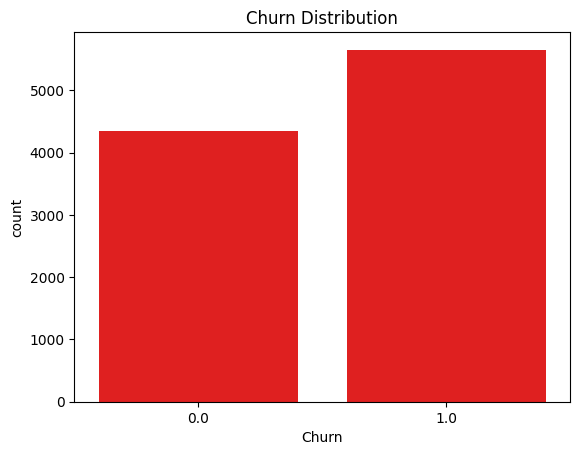

In [11]:
# Checking class distribution

# visualisation of churn distribution
sns.countplot(x="Churn", data=df, color='r')
plt.title("Churn Distribution")
plt.show()

The split showed that the data is not perfectly balanced, but it's a fair split that can be used as-is. Meaning, there's enough comparable data in both classes for the model to learn the unique features inherent.

In [12]:
# let's see the distribution of subscription-type,gender and contract length

for i in ['Subscription Type', 'Gender', 'Contract Length']:
    print(df[i].value_counts(normalize=True))
    print()
    

Subscription Type
Standard    0.3391
Premium     0.3327
Basic       0.3282
Name: proportion, dtype: float64

Gender
Male      0.5712
Female    0.4288
Name: proportion, dtype: float64

Contract Length
Annual       0.4080
Quarterly    0.3883
Monthly      0.2037
Name: proportion, dtype: float64



### <a id='data-encoding'></a>[Data encoding](#toc)

To prepare the data for machine learning, we use the `OrdinalEncoder` from scikit-learn to encode the categorical columns that have some level of hierarchy E.G `Contract Length`. While others like `Gender` will have OH-Encoding. This step ensures that categorical data can be utilized effectively by the model.


In [13]:
ordinal_orders = [['Basic', 'Standard', 'Premium'], # for Subscription Type
                  ['Monthly', 'Quarterly', 'Annual']] # For Contract Length

In [14]:
ord_encoder = OrdinalEncoder(categories=ordinal_orders)

In [15]:
encoded_cols = ord_encoder.fit_transform(df[['Subscription Type', 'Contract Length']])

# Assign the encoded values to the data
df.loc[:, ['Subscription Type', 'Contract Length']] = encoded_cols
print('ordinal encoding done!')

ordinal encoding done!


In [16]:
# see the label encoding
df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,71073.0,27.0,Male,14.0,28.0,3.0,16.0,1.0,0.0,862.00,9.0,1.0
1,230192.0,40.0,Male,19.0,2.0,8.0,28.0,1.0,0.0,620.81,21.0,1.0
2,22407.0,27.0,Female,57.0,3.0,0.0,24.0,1.0,2.0,915.00,26.0,1.0
3,290822.0,40.0,Male,21.0,14.0,0.0,11.0,0.0,2.0,592.83,9.0,0.0
4,172430.0,39.0,Male,58.0,4.0,2.0,8.0,1.0,0.0,694.00,15.0,1.0


In [17]:
# Let's OH-encode the Gender variable
encoded_cols = pd.get_dummies(df["Gender"])
encoded_cols.head(3)

,Female,Male
0,False,True
1,False,True
2,True,False


In [18]:
# now let's insert the male and female column in the position of Gender column 
# and drop Gender

df.insert(2, 'Male', encoded_cols['Male'])
df.insert(2, 'Female', encoded_cols['Female'])
df.drop(columns='Gender', inplace=True)

In [19]:
df.head(3)

,CustomerID,Age,Female,Male,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,71073.0,27.0,False,True,14.0,28.0,3.0,16.0,1.0,0.0,862.00,9.0,1.0
1,230192.0,40.0,False,True,19.0,2.0,8.0,28.0,1.0,0.0,620.81,21.0,1.0
2,22407.0,27.0,True,False,57.0,3.0,0.0,24.0,1.0,2.0,915.00,26.0,1.0


### Selecting the Features and target..

In [20]:
X = df.drop(columns=['CustomerID', 'Churn'])
y = df.Churn
X.head(3)

,Age,Female,Male,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction
0,27.0,False,True,14.0,28.0,3.0,16.0,1.0,0.0,862.00,9.0
1,40.0,False,True,19.0,2.0,8.0,28.0,1.0,0.0,620.81,21.0
2,27.0,True,False,57.0,3.0,0.0,24.0,1.0,2.0,915.00,26.0


#### Scaling \ normalising numeric variables

num_cols = [x for x in list(X) if x not in ['Subscription Type', 
                                            'Contract Length', 
                                            'Male',
                                           'Female']]
num_cols

X[num_cols] = StandardScaler().fit_transform(X[num_cols])

Visualising the normalised dataset, including the ord-encoded values
X.head()  

### <a id='exercise-2-prepare-data-for-model-training'></a>[Prepare data for model training](#toc)

In this exercise, standardize the numerical features of the dataset and split the data into training and testing sets. Train a **RandomForestClassifier** classifier to predict customer churn and visualize the performance of the model using a confusion matrix heatmap.


In [21]:
from sklearn.svm import SVC

In [22]:
r_s = 42 # setting a default random-state value

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=r_s)
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(8000, 11)
(8000,)
(2000, 11)
(2000,)


I will run a default SVC classifier with a few kernels to see which one does the best;

```
kernel{‘linear’, ‘poly’, ‘rbf’, ‘sigmoid’}
```

In [23]:
def choose_best_SVC_kernel():
    kernels = ['linear', 'poly', 'rbf', 'sigmoid']
    best_f1 = ['',0]
    for k in kernels:
        alg = SVC(kernel=k,random_state=r_s)
        alg.fit(X_train, y_train)
        y_p = alg.predict(X_test)
        tn, fp, fn, tp = confusion_matrix(y_test, y_p).ravel().tolist()
        f1 = round(f1_score(y_test, y_p), 4)
        if f1 > best_f1[1]:
            best_f1[0] = k
            best_f1[1] = f1
        print(f"{k}: fp={fp}, fn={fn}")
        print(f'F1: {f1}')
        print()
    print(f'The best Kernel: {best_f1}')

In [24]:
choose_best_SVC_kernel()

linear: fp=107, fn=145
F1: 0.8876

poly: fp=377, fn=187
F1: 0.7717

rbf: fp=51, fn=383
F1: 0.7772

sigmoid: fp=359, fn=381
F1: 0.6723

The best Kernel: ['linear', 0.8876]


From the above, RBF has the fewest False Positives but it does terribly on FN, which is what we should be most concerned with. Therefore, I shall use **Linear** instead, which has the overall best `F1 Score`

In [25]:
svc = SVC(kernel='linear', probability=True, random_state=r_s)
svc

SVC(kernel='linear', probability=True, random_state=42)

In [26]:
# train the model

svc.fit(X_train, y_train)
print('Model Trained!')

Model Trained!


In [27]:
# Predict the Test Data

y_pred = svc.predict(X_test)

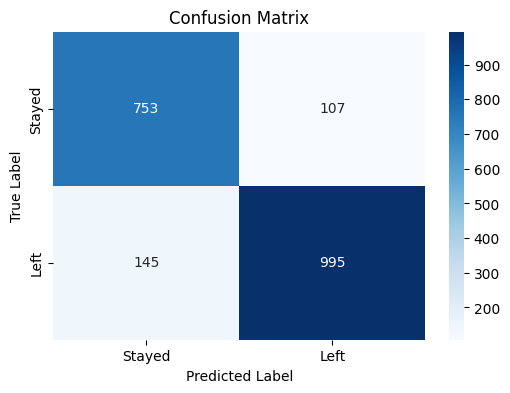

In [28]:
# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Create a heatmap for visualization
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Stayed', 'Left'], yticklabels=['Stayed', 'Left'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

#### Insights from the confusion matrix

1. **Correct predictions**:
   - The model correctly predicted **753 customers who churned** and **995 customers who stayed**.

2. **Incorrect predictions**:
   - **False Positives (107)**: Predicted customers would leave, but they stayed.
   - **False Negatives (145)**: Predicted customers would stay, but they left.

3. **Key takeaways**:
   - The model performs well overall, with most predictions being accurate.
   - Reducing false negatives (customers leaving but predicted to stay) should be prioritised, as these cases are critical for improving retention strategies.


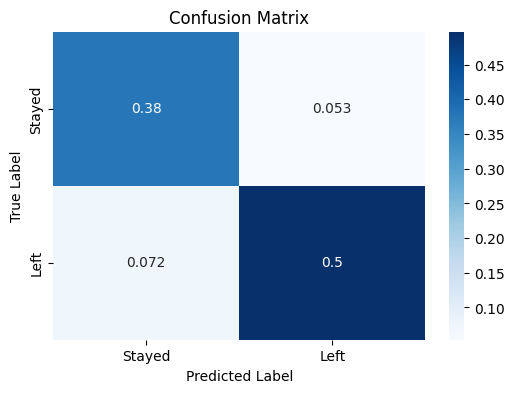

In [29]:
# Generate the confusion matrix with annotation

cm = confusion_matrix(y_test, y_pred, normalize='all')

# Create a heatmap for visualization
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, cmap='Blues', xticklabels=['Stayed', 'Left'], yticklabels=['Stayed', 'Left'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [30]:
from pprint import pprint

pprint(classification_report(y_test, y_pred))

('              precision    recall  f1-score   support\n'
 '\n'
 '         0.0       0.84      0.88      0.86       860\n'
 '         1.0       0.90      0.87      0.89      1140\n'
 '\n'
 '    accuracy                           0.87      2000\n'
 '   macro avg       0.87      0.87      0.87      2000\n'
 'weighted avg       0.88      0.87      0.87      2000\n')


The classification report further shows the strength of the model. It has done relatively well on both classes. F1-score upward of about **86%** in both classes

### <a id='shap-kernel-explainer'></a>[SHAP KernelExplainer](#toc)

Before going to the `KernelExplainer`, let's learn about SHAP first.

#### 1. **What is SHAP?**
   - **SHAP (SHapley Additive exPlanations)** is a framework that helps us understand machine learning models by explaining their predictions.
   - It assigns importance values to each feature in the data to show how much each feature contributes to a specific prediction.
   - **Why and where do we use SHAP?**
     - SHAP is used to make black-box machine learning models (e.g., Random Forests or Neural Networks) interpretable and understandable.
     - For example, in this project, SHAP helps explain why the model predicts that a customer will leave based on features like Tenure, Gender,E.T.C.

#### 2. **What are Shapley values?**
   - Shapley values come from cooperative game theory. They measure how much each "player" (or in our case, each feature) contributes to the "game" (or the model's prediction).
   - Imagine each feature in the dataset is a player contributing to the final prediction. The Shapley value for a feature tells us **how much that feature helps or harms the prediction**, considering all possible combinations of features.
   - **Simple Explanation**:
     - For example, if the prediction is that a customer will leave, Shapley values might tell us that "Tenure" contributes 60% to the prediction, "Support Calls" contributes 30%, and "Gender" contributes 10%.
   - **Why and where do we use Shapley Values?**
     - They allow us to fairly and precisely assign credit to features for their role in a prediction.
     - In this project, Shapley values are used to identify key factors influencing employee retention, making the model's decisions more transparent.
    
#### 3. **What is SHAP KernelExplainer?**
   - The **SHAP KernelExplainer** is a tool within SHAP that works with any type of machine learning model, even the most complex ones like Random Forests or Neural Networks.
   - It calculates Shapley values using **weighted linear regression**, which simplifies how we compute the importance of each feature.
   - We all know about Linear regression, **Weighted Linear Regression** adds a twist: it gives more importance (weight) to certain data points when finding the best-fit line. In KernelExplainer, this helps focus on the most relevant data points for a specific prediction.
   - In our case, it helps calculate how important each feature (e.g., salary, satisfaction) is to the model's decision.

#### **How does it add to the project?**
   - **Feature-Level Insights**: SHAP KernelExplainer tells us exactly how each feature impacts the model’s prediction for an employee (e.g., "low satisfaction level" increases the chance of leaving).
   - **Model Transparency**: It makes the `RandomForestClassifier` more interpretable by explaining why the model makes specific decisions.
   - **Actionable Insights**: By identifying features that drive employee attrition, it helps HR teams focus on areas that need attention (e.g., improving satisfaction or reducing workload).
   - **A Complete Explanation Framework**: Combined with other techniques like Protodash, SHAP KernelExplainer provides a deeper understanding of the model's behavior at the feature level.

In summary, SHAP KernelExplainer is an essential tool in this project, making the predictions interpretable, actionable, and trustworthy. If you want to learn more about SHAP visit their [documentation](https://shap.readthedocs.io/en/latest/).


In [31]:
# Create a k-means summary of the entire training data
# Using k=50 or k=100 is a good starting point
# This is MUCH faster than using the whole X_train

background_data = shap.kmeans(X_train, 10) # just using 10 to speed things up a bit

In [32]:
# Pass the model's prediction function and the background data to Kernel Explainer

explainer = shap.KernelExplainer(svc.predict_proba, background_data)

In [33]:
# Calculate SHAP values for the test set
# This can be slow!

shap_values = explainer.shap_values(X_test)

In [34]:
# Plot summary of SHAP values for class 1 (customers who left)
shap.summary_plot(shap_values[...,1], X, plot_type="bar", feature_names=X.columns)
plt.savefig('shap_values1.png')

In [35]:
# Let's see the shape of the SHAP values
shap_values.shape

### <a id='explanation-mapping'></a>[Explanation mapping](#toc)

We define a mapping that links potential reasons for employee attrition to unique explanation codes. The `generate_explanation_code` function aligns SHAP value rankings with prioritized factors (e.g., satisfaction, workload, salary) to identify the primary reason behind each prediction. This ensures the explanation highlights the most impactful factor, offering HR teams clear, actionable insights for addressing retention challenges.


I used the Gemini Advanced 2.5 Pro model with a detailed prompt to produce the domain expert explanations, and action plans seen in the two dictionaries below

In [36]:
# Creating a Nested Dictionary of explanations

expl_mapping = { 1: {'Expl': 'High-risk monthly contract with frequent support issues.',
                     'Persona': 'The "Frustrated & Uncommitted" Customer.',
                     "Priority": 'Immediately resolve ALL active queries to mitigate the combined risk of frequent calls and a monthly contract:'
                    },
                
                2: {'Expl': 'New customer with low engagement and spend.', 
                     'Persona': 'The "Failed Onboarding" Customer.',
                    'Priority': 'Drive immediate engagement for new users to establish early value and customer loyalty:'
                   },
                
                3: {'Expl': 'High number of support calls.', 
                     'Persona': 'The "High-Friction" Customer.',
                   'Priority': 'Resolve ALL active queries to mitigate customer frustration & churn:'
                   },
                
                4: {'Expl': 'Customer is on a high-risk monthly contract.', 
                     'Persona': 'The "Uncommitted Client".',
                   'Priority': 'Create retention programs to offset the structural risk of no monthly commitment:'
                   },
                
                5: {'Expl': "Significant payment delays.", 
                     'Persona': 'The "Financial Risk" Customer.',
                   'Priority': 'Design payment intervention plans, diagnose delays and boost commitment:'
                   },
                
                6: {'Expl': "Low total spend and engagement.", 
                     'Persona': 'The "Disengaged Customer".',
                   'Priority':'Drive product adoption & demonstrate value to increase future spend:'},
                
                7: {'Expl': "Low usage frequency.", 
                     'Persona': 'The "Unengaged User".',
                   'Priority': 'Demonstrate value to drive customer usage and engagement:'
                   },
                
                8: {'Expl': "New customer with short tenure.", 
                     'Persona': 'The "Onboarding Risk" Customer.',
                   'Priority': 'Create value realisation to drive loyalty and engagement:'}
               }

In [37]:
# Creating a Nested Dictionary of corresponding timely action plans

timely_actions = {
    1: {
        'Timely Actions:': "1. Immediately flag for a senior support agent to review the customer's full ticket history and make a direct outreach call to resolve the underlying issues.\n2. Incentivise Commitment: Once the support issue is resolved, offer a significant, personalised discount (e.g., 20% off) to switch to an annual contract, locking them in and rewarding their patience."
    },
    
    2: {
        'Timely Actions:': "1. Automated Re-engagement: Trigger a targeted email campaign highlighting key, unused features and showcasing relevant case studies.\n2. Personalised Guidance: Offer a free, 15-minute \"pro-setup\" call with a customer success specialist to help them integrate the service into their workflow and achieve an \"aha!\" moment."
    },

    3: {
        'Timely Actions:': "1. Flag for Monitoring: Mark the customer's account in the CRM for proactive monitoring of their product usage and future support interactions.\n2. Escalate & Consolidate: Have a support team lead analyse their ticket history for patterns. Escalate to a senior agent to consolidate all open issues into one resolution effort."
    },

    4: {
        'Timely Actions:': "1. Marketing Nurture: Enrol the customer into an automated marketing track that periodically messages the cost-saving benefits and stability of an annual plan.\n2. Targeted Sales Offer: After 3-4 months of consistent usage, trigger a task for a sales representative to offer a time-limited discount to upgrade to a yearly contract."
    },

    5: {
        'Timely Actions:': "1. Automated Checks: Ensure automated dunning emails are active and check for simple issues like expired credit cards.\n2. Human Touch: If payment fails more than twice, have an account manager reach out personally. The goal is to be helpful (offering payment plans) rather than just demanding, to determine if it's a financial issue or a sign of lost interest."
    },

    6: {
        'Timely Actions:': "1. Trigger an automated email campaign highlighting unused, high-value features (e.g., portfolio analysis, savings goals).\n2. Offer a complimentary \"financial health check-up\" session with a specialist to demonstrate the product's full value."
    },

    7: {
        'Timely Actions:': "1. Automated Nudge: Trigger a targeted email campaign showcasing a high-value, unused feature to solve a common problem.\n2. Proactive Guidance: Offer a complimentary \"account review\" or \"health check-up\" with a specialist to demonstrate the product's full potential.\n3. Feedback Loop: If usage remains low, send a one-question survey to identify missing features or points of friction."
    },

    8: {
        'Timely Actions:': "1. Ensure the customer is in a high-touch onboarding campaign with relevant tutorials and financial planning use-cases.\n2. Schedule a proactive 30-day check-in call from a Customer Success Manager to ensure they have met their initial goals."
    }
}

In [38]:
def generate_explanation_code(row):
    """
    Generates a prioritized, human-readable explanation for customer churn risk
    using both single and compound feature conditions.
    """
    # Priority 1 (Compound): A customer on a risky contract who is actively having issues.
    # This is a very strong signal for immediate churn risk.
    if row["Contract Length"] == 0 and row["Support Calls"] >= 3:
        return 1 #"High-risk monthly contract with frequent support issues"
        
    # Priority 2 (Compound): A new customer who is not engaged or spending much.
    # This identifies customers who failed to find value early on.
    elif row["Tenure"] <= 6 and row["Total Spend"] <= 250:
        return 2 #"New customer with low engagement and spend"
        
    # Priority 3 (Single): Catches remaining cases with high support calls.
    # Still the most important single factor from the SHAP analysis.
    elif row["Support Calls"] > 4:
        return 3 #"High number of support calls"
        
    # Priority 4 (Single): Catches remaining high-risk monthly contracts.
    elif row["Contract Length"] == 0:
        return 4 # "Customer is on a high-risk monthly contract"
        
    # Priority 5 (Single): Catches customers with payment problems.
    elif row["Payment Delay"] > 25:
        return 5 # "Significant payment delays"

    # Priority 6 (Single):
    elif row["Total Spend"] <= 250: # Threshold for what's considered "low spend"
        return 6 # "Low total spend and engagement"
        
    # Priority 7 (Single):
    elif row["Usage Frequency"] <= 7:
        return 7 # "Low usage frequency"
        
    # Priority 8 (Single):
    elif row['Tenure'] >= 6:
        return 8 # "New customer with short tenure"
        
    # Default case if no other strong signal is found.
    else:
        return 9 # "General churn risk factors: Use SHAP values"

In [39]:
def get_explanation(code, actions=False):
    """Get detailed explanations for each customer based on their code
    @param actions: This determines if we want action plans also
    @return: A dictionary or two(including actions=True)
    """
    return expl_mapping[code]

In [40]:
df.head(3)

,CustomerID,Age,Female,Male,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,71073.0,27.0,False,True,14.0,28.0,3.0,16.0,1.0,0.0,862.00,9.0,1.0
1,230192.0,40.0,False,True,19.0,2.0,8.0,28.0,1.0,0.0,620.81,21.0,1.0
2,22407.0,27.0,True,False,57.0,3.0,0.0,24.0,1.0,2.0,915.00,26.0,1.0


In [41]:
# Apply the explanations to the entire dataset

df['Explanation'] = df.apply(generate_explanation_code, axis=1)

# Display a sample explanation to verify the encoding
print(df['Explanation'].head())

0    1
1    1
2    7
3    8
4    4
Name: Explanation, dtype: int64


In [42]:
# let's see the unique explanation codes in the data

df.Explanation.unique()  # this shows all codes from 1 to 9

array([1, 7, 8, 4, 3, 9, 5, 2, 6])

In [43]:
# So, for the first customer with churn code 1, we can see the explanation

get_explanation(1)

{'Expl': 'High-risk monthly contract with frequent support issues.',
 'Persona': 'The "Frustrated & Uncommitted" Customer.',
 'Priority': 'Immediately resolve ALL active queries to mitigate the combined risk of frequent calls and a monthly contract:'}

In [45]:
# We can do same for the 5th customer with explanation code 4

get_explanation(4)

{'Expl': 'Customer is on a high-risk monthly contract.',
 'Persona': 'The "Uncommitted Client".',
 'Priority': 'Create retention programs to offset the structural risk of no monthly commitment:'}

#### <a id='Using SHAP values'></a>[Using SHAP values](#toc)

So, from the SHAP values, we want to find the maximum feature affecting each customers churn and from these create explanations and HR plans for the future.

Here’s the process:

* For a single customer, get the array of their SHAP values (one value per feature).

* Find the index of the value with the largest magnitude (absolute value).

* Get the name of the feature at that index.

* Use this feature name to retrieve the Explanation Code and Narrative from your mapping.


**The overriding idea is to default to the Argmax shap value(feature) for a given customer who is likely to churn, if this customer doesn't fit clearly into the designated groups identified by the Domain Experts. These customers would be given the `9` explanation code.**

**This beautifully combines SHAP scores and Domain Expertise to produce robust explanations and action plans.**

In [46]:
# 1. Find the index of the feature with the highest absolute SHAP value for each row
# We use shap_values[:,:,1].values for the positive (churn) class
primary_feature_indices = np.argmax(np.abs(shap_values[:,:,1]), axis=1)

# 2. Get the names of the most impactful features for the entire dataset
primary_features = X.columns[primary_feature_indices]

In [47]:
len(primary_features)

### <a id='training-the-ted-cartesian-explainer-model'></a>[Training the TED_CartesianExplainer model](#toc)

The `TED_CartesianExplainer` is an explainability tool that links machine learning predictions to human-readable explanations. This makes complex models easier to understand for end users, such as HR teams or managers.

#### What is TED_CartesianExplainer?
- It maps features or feature combinations to predefined explanations, helping interpret predictions in context.
- For example, it can explain predictions like "Low satisfaction level may lead to leaving" based on the features' impact.
- It integrates predictions and explanations into a unified framework, ensuring clarity and consistency.

#### How is TED_CartesianExplainer different?
| Aspect                        | TED_CartesianExplainer                                                                                  | Traditional Models                                                                                        |
|-------------------------------|---------------------------------------------------------------------------------------------------------|-----------------------------------------------------------------------------------------------------------|
| **Focus on Explanations**     | Provides feature-level insights tied to predictions, making them actionable (e.g., "Low salary impacts attrition"). | Predicts outcomes but does not inherently provide reasons behind predictions.                             |
| **Integration of Explanations** | Combines predictions and explanations into one framework for consistency.                              | Requires additional tools like SHAP or LIME for post-hoc explanations.                                   |
| **Actionable Insights**       | Highlights critical factors for decision-making, aligned with domain knowledge.                        | Focuses on performance but lacks built-in interpretability.                                               |

#### Why use TED for employee retention?
- **Explain Predictions**: Understand why the model predicts an employee might leave or stay.
- **Highlight Key Factors**: Identify critical drivers like low satisfaction or high workload.
- **Build Trust**: Enable HR teams to trust AI predictions with clear, interpretable explanations.

By linking predictions to specific features, `TED_CartesianExplainer` provides actionable insights to address employee retention challenges effectively. If you want to learn more about the model, read the original paper on [Arxiv](https://arxiv.org/pdf/1811.04896).


Now, let's move on with the training. First, we divide the dataset into three parts, `X` (whole dataset without `Churn` and `Explanation` feature), `Y` (target column `Churn`) and E (containing all the `Explanation` that we mapped).


In [48]:
df.head()

,CustomerID,Age,Female,Male,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn,Explanation
0,71073.0,27.0,False,True,14.0,28.0,3.0,16.0,1.0,0.0,862.00,9.0,1.0,1
1,230192.0,40.0,False,True,19.0,2.0,8.0,28.0,1.0,0.0,620.81,21.0,1.0,1
2,22407.0,27.0,True,False,57.0,3.0,0.0,24.0,1.0,2.0,915.00,26.0,1.0,7
3,290822.0,40.0,False,True,21.0,14.0,0.0,11.0,0.0,2.0,592.83,9.0,0.0,8
4,172430.0,39.0,False,True,58.0,4.0,2.0,8.0,1.0,0.0,694.00,15.0,1.0,4


In [49]:
# Decompose the dataset into X, Y, E
X = df.drop(columns=['Churn', 'Explanation', 'CustomerID'])
Y = df['Churn']
E = df['Explanation']

In [50]:
print(X.shape)
print(Y.shape)
print(E.shape)

(10000, 11)
(10000,)
(10000,)


In [51]:
# Split all into train and test sets
X_train, X_test, Y_train, Y_test, E_train, E_test = train_test_split(X, Y, E, test_size=0.20, random_state=r_s)

In [52]:
print(X_train.shape)
print(Y_train.shape)
print(E_train.shape)
print(X_test.shape)
print(Y_test.shape)
print(E_test.shape)

(8000, 11)
(8000,)
(8000,)
(2000, 11)
(2000,)
(2000,)


We now initialize the `TED_CartesianExplainer`, a tool from AIX360, with a machine learning model (e.g., `RandomForestClassifier`). This explainer associates the model’s predictions with predefined, human-readable explanations, enabling feature-level insights into why specific predictions were made. By linking features to domain-relevant explanations, it enhances the interpretability and trustworthiness of the model.


In [53]:
ted = TED_CartesianExplainer(svc)

In [54]:
print("Training the classifier")

ted.fit(X_train, Y_train, E_train)   # train classifier

print("Training finished")

Training the classifier
Training finished


### <a id='accuracy-of-the-model'></a>[Accuracy of the model](#toc)

We can evaluate the accuracy of the model using the `.score` method. This method assesses the following:

- **Target label accuracy (`Y`)**: Measures how accurately the model predicts the target labels.
- **Explanation accuracy (`E`)**: Evaluates the accuracy of the explanations provided by the model.
- **Combined accuracy (`Y+E`)**: Combines the accuracy of predicting both the target labels and their corresponding explanations.

The **Y+E accuracy** reflects how well the classifier performs in making correct predictions while also providing accurate and meaningful explanations. This metric is essential for ensuring that the model's outputs are both reliable and interpretable, building trust and confidence in its decisions.


In [55]:
X_test.head()

,Age,Female,Male,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction
6252,56.0,True,False,26.0,16.0,0.0,11.0,2.0,0.0,427.00,8.0
4684,36.0,True,False,56.0,17.0,2.0,18.0,0.0,1.0,906.72,2.0
1731,48.0,False,True,55.0,6.0,1.0,11.0,1.0,1.0,541.29,27.0
4742,58.0,True,False,30.0,3.0,10.0,27.0,2.0,2.0,429.00,26.0
4521,27.0,False,True,35.0,3.0,1.0,16.0,1.0,2.0,983.71,10.0


In [56]:
ted.predict_explain(X_test.head(3))

(array([1., 0., 1.]), array([4., 8., 7.]))

In [57]:
# Evaluate the TED model on the test dataset
YE_accuracy, Y_accuracy, E_accuracy = ted.score(X_test, Y_test.values, E_test.values)

print("\nEvaluating accuracy of TED-enhanced classifier on test data")
print(' Accuracy of predicting Y labels: %.2f%%' % (100 * Y_accuracy))
print(' Accuracy of predicting Explanations: %.2f%%' % (100 * E_accuracy))
print(' Accuracy of predicting Y + Explanations: %.2f%%' % (100 * YE_accuracy))


Evaluating accuracy of TED-enhanced classifier on test data
 Accuracy of predicting Y labels: 93.40%
 Accuracy of predicting Explanations: 99.50%
 Accuracy of predicting Y + Explanations: 92.90%


## <a id='integration-with-genai'></a>[Integration with generative AI](#toc)


In this section, we integrate generative AI (gen AI) with Explainable AI (XAI) to provide enriched insights and actionable outputs. Using Google’s `GenAI` model, we will generate detailed natural language explanations for model predictions and create HR action plans to address employee attrition risks. This integration bridges the gap between predictive analytics and strategic decision-making, making the model's outputs more interpretable and practical for HR teams.


In [58]:
from kaggle_secrets import UserSecretsClient

user_secrets = UserSecretsClient()
secret_value_0 = user_secrets.get_secret("GEMINI_API_KEY")

In [59]:
# 1. Use the CORRECT import
import google.generativeai as genai

# 2. Configure your API key
genai.configure(api_key=secret_value_0)

print("Available models:")

for model in genai.list_models():
    # Filter for models you can use with .generate_content()
    if 'generateContent' in model.supported_generation_methods:
        print(model.name)

Available models:
models/gemini-2.5-pro-preview-03-25
models/gemini-2.5-flash-preview-05-20
models/gemini-2.5-flash
models/gemini-2.5-flash-lite-preview-06-17
models/gemini-2.5-pro-preview-05-06
models/gemini-2.5-pro-preview-06-05
models/gemini-2.5-pro
models/gemini-2.0-flash-exp
models/gemini-2.0-flash
models/gemini-2.0-flash-001
models/gemini-2.0-flash-exp-image-generation
models/gemini-2.0-flash-lite-001
models/gemini-2.0-flash-lite
models/gemini-2.0-flash-preview-image-generation
models/gemini-2.0-flash-lite-preview-02-05
models/gemini-2.0-flash-lite-preview
models/gemini-2.0-pro-exp
models/gemini-2.0-pro-exp-02-05
models/gemini-exp-1206
models/gemini-2.0-flash-thinking-exp-01-21
models/gemini-2.0-flash-thinking-exp
models/gemini-2.0-flash-thinking-exp-1219
models/gemini-2.5-flash-preview-tts
models/gemini-2.5-pro-preview-tts
models/learnlm-2.0-flash-experimental
models/gemma-3-1b-it
models/gemma-3-4b-it
models/gemma-3-12b-it
models/gemma-3-27b-it
models/gemma-3n-e4b-it
models/gemm

I will put these in a function

In [74]:
model = genai.GenerativeModel('gemini-2.5-flash-lite')
prompt = 'Suggest actionable HR strategies to address this issue: '

def create_HR_action_plans(customer_code=None, prompt=prompt, model=model):
    expl = str(get_explanation(customer_code))
    print(expl)
    print()
    structure ='\nRespond in plain text without markdown formats.'
    config = {
        "response_mime_type": "text/plain"
    }

    response = model.generate_content(
        f"{prompt}{expl}{structure}",
        generation_config=config
    )

    # 5. Print the clean, plain text
    print(response.text)

In [76]:
create_HR_action_plans(customer_code=1)

{'Expl': 'High-risk monthly contract with frequent support issues.', 'Persona': 'The "Frustrated & Uncommitted" Customer.', 'Priority': 'Immediately resolve ALL active queries to mitigate the combined risk of frequent calls and a monthly contract:'}

Here are actionable HR strategies to address the "High-risk monthly contract with frequent support issues" faced by a "Frustrated & Uncommitted" Customer, with the priority of "Immediately resolve ALL active queries to mitigate the combined risk of frequent calls and a monthly contract":

**Immediate Actions (Focus on resolving active queries):**

1.  **Dedicated "Firefighter" Support Team:**
    *   **Strategy:** Assign a small, highly skilled, and empowered support team specifically to this customer's account for the next 24-48 hours.
    *   **Action:** Identify top-tier support technicians with strong problem-solving skills and deep product knowledge. Grant them elevated access and authority to expedite resolutions. This team's sole fo

```
Evaluating accuracy of TED-enhanced classifier on test data with:
1. SVC, linear kernel, not-normalised data, Gemini Rules
 Accuracy of predicting Y labels: 93.40%
 Accuracy of predicting explanations: 99.50%
 Accuracy of predicting Y + explanations: 92.90%
```

```
Evaluating accuracy of TED-enhanced classifier on test data with:
1. SVC, linear kernel, not-normalised data, ibm few rules:
 Accuracy of predicting Y labels: 90.80%
 Accuracy of predicting explanations: 100.00%
 Accuracy of predicting Y + explanations: 90.80%
```

```
Evaluating accuracy of TED-enhanced classifier on test data with:
1. SVC, rbf kernel, normalised data and gemini rules:
 Accuracy of predicting Y labels: 69.50%
 Accuracy of predicting explanations: 45.65%
 Accuracy of predicting Y + explanations: 41.40%
```